<a href="https://colab.research.google.com/github/apesnajnin1/PGD-in-Machine-Learning_python-based/blob/main/ml_final_project_code_Najnin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Literacy and Vocational Training: Persons with Disabilities vs General Population
ML final project (Linear, Ridge, Lasso, Decision Tree and Random Forest regression).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Path("results").mkdir(exist_ok=True)

## 1. Load the data

In [4]:
from google.colab import files
uploaded = files.upload()
DATA_PATH = next(iter(uploaded))

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig", keep_default_na=False, na_values=[""])
print("Rows and columns:", df.shape)
print(df.head())

Saving Education_Vocational_Training_DILFS2022_LFS2024.csv to Education_Vocational_Training_DILFS2022_LFS2024 (1).csv
Rows and columns: (750, 12)
       survey  survey_year                          population  \
0  DILFS 2022         2022  Persons with disabilities aged 15+   
1  DILFS 2022         2022  Persons with disabilities aged 15+   
2  DILFS 2022         2022  Persons with disabilities aged 15+   
3  DILFS 2022         2022  Persons with disabilities aged 15+   
4  DILFS 2022         2022  Persons with disabilities aged 15+   

                                             chapter table_no  \
0  Chapter 3: Education and Vocational Training o...      3.1   
1  Chapter 3: Education and Vocational Training o...      3.1   
2  Chapter 3: Education and Vocational Training o...      3.1   
3  Chapter 3: Education and Vocational Training o...      3.1   
4  Chapter 3: Education and Vocational Training o...      3.1   

                                         table_title    category  

## 2. Data cleaning: missing values, duplicates, consistent labels

In [5]:
print("\nMissing values per column:")
print(df.isnull().sum())

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])                    # remove rows without a usable value

print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# LFS writes 'Bangladesh', DILFS writes 'National' -> same meaning
df["locality"] = df["locality"].replace({"Bangladesh": "National"})
# population flag: persons with disabilities (DILFS 2022) vs general population (LFS 2024)
df["group"] = np.where(df["survey"].str.startswith("DILFS"), "Disabled", "General")


Missing values per column:
survey         0
survey_year    0
population     0
chapter        0
table_no       0
table_title    0
category       0
locality       0
sex            0
measure        0
unit           0
value          0
dtype: int64

Duplicate rows: 0


## 3. Harmonised tables (so the two surveys can be compared)

In [6]:
# 3a. Literacy rate: general (LFS 2024, table 4.1.1) vs disabled (DILFS 2022, table 3.1)
gen = df[(df.survey == "LFS 2024") & (df.table_no == "4.1.1") & (df.locality == "National")
         & (df.category == "Total")].set_index("sex")["value"]
dis = df[(df.survey == "DILFS 2022") & (df.table_no == "3.1") & (df.category == "Literate")
         ].set_index("sex")["value"]
gap = pd.DataFrame({"General_2024": gen, "Disabled_2022": dis}).reindex(["Male", "Female", "Total"])
gap["Gap_pct_points"] = gap["General_2024"] - gap["Disabled_2022"]
print("\nLiteracy rate (%):")
print(gap.round(2))

# 3b. Training types: LFS lists 23 types, DILFS 11 -> keep the shared ones, the rest become 'Other'
types = df[((df.survey == "DILFS 2022") & (df.table_no == "3.5")) |
           ((df.survey == "LFS 2024") & (df.table_no == "4.3.3"))].copy()
types = types[types.category != "Total"]
shared = set(types[types.survey == "DILFS 2022"].category) - {"Other"}
types["category"] = np.where(types.category.isin(shared), types.category, "Other")
types = types.groupby(["group", "locality", "sex", "category"], as_index=False)["value"].sum()
types["topic"] = "training_type"

# 3c. Training duration
dur = df[((df.survey == "DILFS 2022") & (df.table_no == "3.4")) |
         ((df.survey == "LFS 2024") & (df.table_no == "4.3.2"))].copy()
dur = dur[dur.category != "Total"][["group", "locality", "sex", "category", "value"]]
dur["topic"] = "training_duration"

# sanity check: every distribution must add up to about 100 %
for name, t in [("types", types), ("duration", dur)]:
    sums = t.groupby(["group", "locality", "sex"])["value"].sum()
    print(name, "- largest deviation from 100 %:", round((sums - 100).abs().max(), 2))


Literacy rate (%):
        General_2024  Disabled_2022  Gap_pct_points
sex                                                
Male           80.50          44.98           35.52
Female         77.49          28.02           49.47
Total          78.98          37.11           41.87
types - largest deviation from 100 %: 0.0
duration - largest deviation from 100 %: 0.0


## 4. Charts: research findings

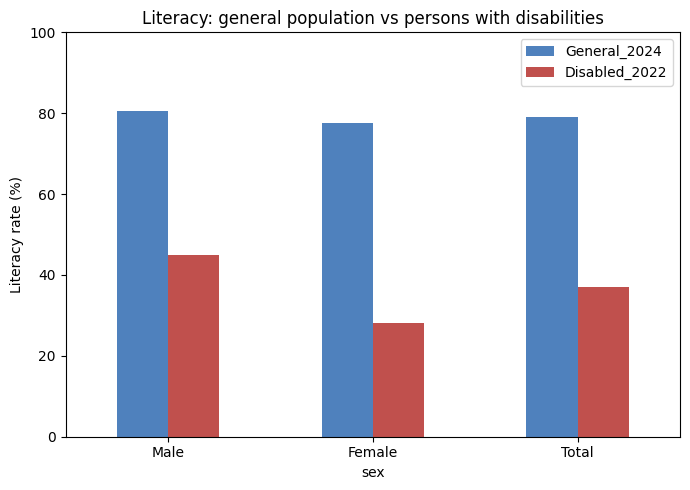

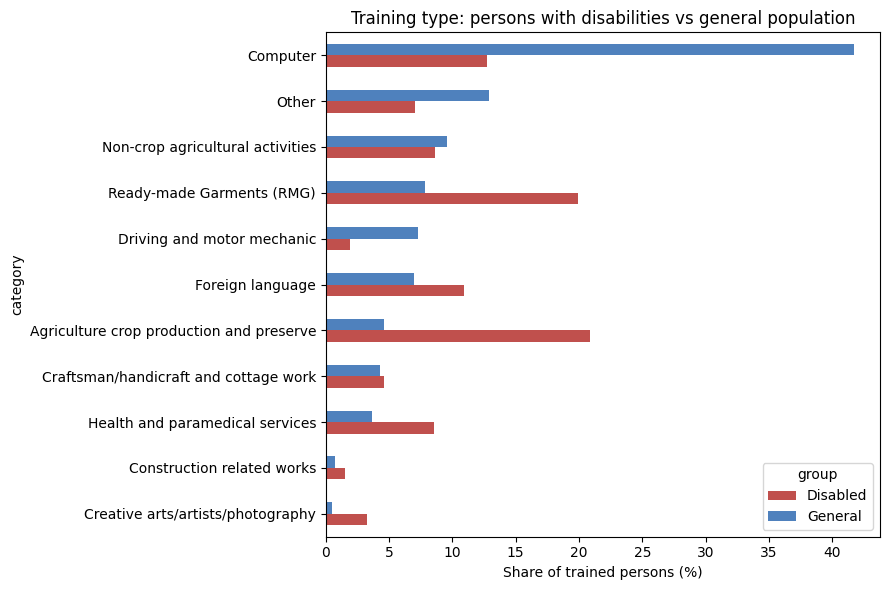

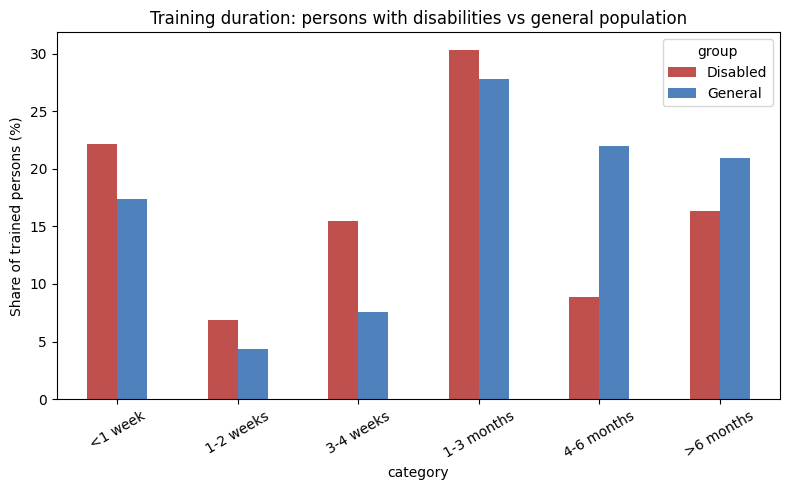

In [7]:
# Chart 1: literacy gap
gap[["General_2024", "Disabled_2022"]].plot(kind="bar", figsize=(7, 5), color=["#4f81bd", "#c0504d"])
plt.ylabel("Literacy rate (%)")
plt.title("Literacy: general population vs persons with disabilities")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("results/fig1_literacy_gap.png", dpi=200)
plt.show()

# Chart 2: training types, national level, both sexes
nat_types = types[(types.locality == "National") & (types.sex == "Total")]
p = nat_types.pivot(index="category", columns="group", values="value").fillna(0)
p = p.sort_values("General", ascending=True)
p[["Disabled", "General"]].plot(kind="barh", figsize=(9, 6), color=["#c0504d", "#4f81bd"])
plt.xlabel("Share of trained persons (%)")
plt.title("Training type: persons with disabilities vs general population")
plt.tight_layout()
plt.savefig("results/fig2_training_types.png", dpi=200)
plt.show()

# Chart 3: training duration, national level, both sexes
order = ["<1 week", "1-2 weeks", "3-4 weeks", "1-3 months", "4-6 months", ">6 months"]
nat_dur = dur[(dur.locality == "National") & (dur.sex == "Total")]
p = nat_dur.pivot(index="category", columns="group", values="value").reindex(order)
p[["Disabled", "General"]].plot(kind="bar", figsize=(8, 5), color=["#c0504d", "#4f81bd"])
plt.ylabel("Share of trained persons (%)")
plt.title("Training duration: persons with disabilities vs general population")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("results/fig3_training_duration.png", dpi=200)
plt.show()

## 5. Build the machine learning dataset

In [33]:
# One row = share (%) of one training type / duration for one (group, sex, locality) combination.
data = pd.concat([types, dur], ignore_index=True)

# 'Total' sex rows are calculated from Male and Female -> drop them (data leakage)
data = data[data.sex.isin(["Male", "Female"])].reset_index(drop=True)
print("\nML dataset:", data.shape)


ML dataset: (136, 6)


## 6. Outliers: IQR method and Z-score method (checked separately for each topic)

training_type: IQR fences [0.0, 31.5] -> 6 outliers, Z-score (|z| > 3) -> 2 outliers
training_duration: IQR fences [0.0, 45.2] -> 1 outliers, Z-score (|z| > 3) -> 0 outliers


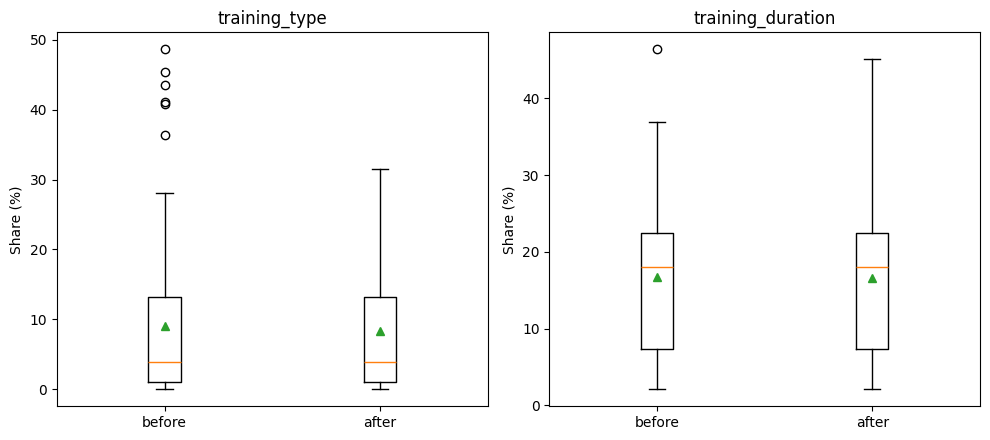

In [34]:
# %% 6. Outliers: IQR method and Z-score method (checked separately for each topic)
import numpy as np
import pandas as pd

# Smart Fallback: If 'data' is missing but 'types' is available from the previous step, build 'data'
if "data" not in globals():
    if "types" in globals():
        data = types.copy()
        # Ensure the loop has a "topic" column to iterate over
        if "topic" not in data.columns:
            if "type" in data.columns:
                data["topic"] = data["type"]
            else:
                data["topic"] = "Training Share"
    else:
        # If absolutely no data structures exist, raise the structural alert
        raise NameError("'data' is not defined - run the cells above first (Runtime > Run all).")

# Keep the original values once; on a re-run, start again from the original values
if "value_raw" not in data.columns:
    data["value_raw"] = data["value"]

data["value"] = data["value_raw"]

# Execute the topic outlier scanning loop safely
for topic in data["topic"].unique():
    v = data.loc[data.topic == topic, "value"]

# IQR method
    Q1, Q3 = v.quantile(0.25), v.quantile(0.75)
    IQR = Q3 - Q1
    lower = max(Q1 - 1.5 * IQR, 0)          # a share cannot be below 0 %
    upper = Q3 + 1.5 * IQR
    n_iqr = ((v < lower) | (v > upper)).sum()

    # Z-score method
    z = (v - v.mean()) / v.std()
    n_z = (z.abs() > 3).sum()

    print(f"{topic}: IQR fences [{lower:.1f}, {upper:.1f}] -> {n_iqr} outliers, "
          f"Z-score (|z| > 3) -> {n_z} outliers")

    # treatment: cap (winsorise) at the IQR fences, so no row is lost
    data.loc[data.topic == topic, "value"] = v.clip(lower, upper)

# boxplot before and after the treatment
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, topic in zip(axes, data["topic"].unique()):
    g = data[data.topic == topic]
    ax.boxplot([g["value_raw"], g["value"]], showmeans=True)
    ax.set_xticklabels(["before", "after"])
    ax.set_title(topic)
    ax.set_ylabel("Share (%)")
plt.tight_layout()
plt.savefig("results/fig4_outliers.png", dpi=200)
plt.show()


## 7. Feature engineering

In [14]:
data["is_disabled"] = (data.group == "Disabled").astype(int)
data["is_female"] = (data.sex == "Female").astype(int)
data["is_rural"] = (data.locality == "Rural").astype(int)
data["is_urban"] = (data.locality == "Urban").astype(int)
data["female_x_disabled"] = data.is_female * data.is_disabled      # interaction feature

# encoding: one-hot encode the training type / duration category
X = pd.concat([data[["is_disabled", "is_female", "is_rural", "is_urban", "female_x_disabled"]],
               pd.get_dummies(data["category"], dtype=int)], axis=1)
y = data["value"]
print("X shape:", X.shape, " y shape:", y.shape)

X shape: (132, 16)  y shape: (132,)


## 8. Train / test split and feature scaling (StandardScaler only)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling: fit on the training data only, then apply to the test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
print (X_train)

     is_disabled  is_female  is_rural  is_urban  female_x_disabled  \
95             0          0         1         0                  0   
96             0          0         1         0                  0   
0              1          1         0         0                  1   
12             1          0         0         0                  0   
126            0          0         0         1                  0   
..           ...        ...       ...       ...                ...   
71             0          1         1         0                  0   
106            0          1         0         1                  0   
14             1          0         0         0                  0   
92             0          0         1         0                  0   
102            0          1         0         1                  0   

     Agriculture crop production and preserve  Computer  \
95                                          0         0   
96                                       

In [19]:
print(y_train)

95      3.40
96     13.39
0       5.35
12     18.56
126     6.32
       ...  
71      0.00
106     1.10
14      0.00
92      0.07
102     5.60
Name: value, Length: 105, dtype: float64


## 9. Define the models

In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, random_state=42, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
}

## 10. Train, predict and evaluate every model

In [21]:
results = []
predictions = {}
for name, clf in models.items():
    # Train the model
    clf.fit(X_train_scaled, y_train)

    # Make predictions on test set
    pred = clf.predict(X_test_scaled)
    predictions[name] = pred

    # Calculate performance metrics
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    print(f"\n{name} Performance Metrics:")
    print('Mean Squared Error (MSE): {:.2f}'.format(mse))
    print('Root Mean Squared Error (RMSE): {:.2f}'.format(rmse))
    print('Mean Absolute Error (MAE): {:.2f}'.format(mae))
    print('R2 Score: {:.2f}'.format(r2))

    results.append({"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2})


Linear Regression Performance Metrics:
Mean Squared Error (MSE): 37.28
Root Mean Squared Error (RMSE): 6.11
Mean Absolute Error (MAE): 4.26
R2 Score: 0.57

Ridge Regression Performance Metrics:
Mean Squared Error (MSE): 37.35
Root Mean Squared Error (RMSE): 6.11
Mean Absolute Error (MAE): 4.27
R2 Score: 0.57

Lasso Regression Performance Metrics:
Mean Squared Error (MSE): 37.10
Root Mean Squared Error (RMSE): 6.09
Mean Absolute Error (MAE): 4.24
R2 Score: 0.57

Decision Tree Performance Metrics:
Mean Squared Error (MSE): 33.36
Root Mean Squared Error (RMSE): 5.78
Mean Absolute Error (MAE): 3.83
R2 Score: 0.61

Random Forest Performance Metrics:
Mean Squared Error (MSE): 20.85
Root Mean Squared Error (RMSE): 4.57
Mean Absolute Error (MAE): 2.90
R2 Score: 0.76


## 11. Results table and comparison chart


Model comparison (test set):
            Model    MSE  RMSE   MAE    R2
    Random Forest 20.855 4.567 2.897 0.758
    Decision Tree 33.357 5.776 3.830 0.613
 Lasso Regression 37.099 6.091 4.244 0.570
Linear Regression 37.279 6.106 4.257 0.568
 Ridge Regression 37.353 6.112 4.273 0.567


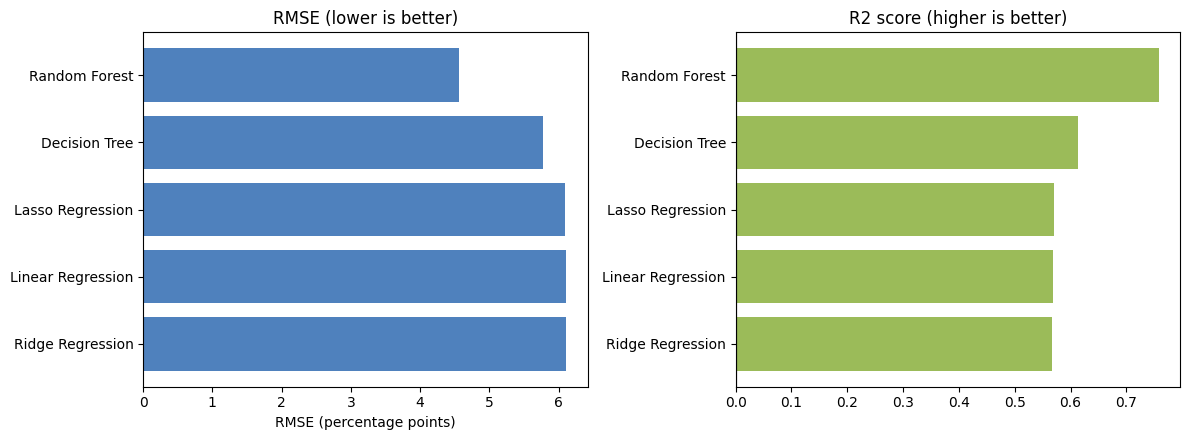

In [22]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("\nModel comparison (test set):")
print(results_df.round(3).to_string(index=False))
results_df.to_csv("results/model_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
r = results_df.iloc[::-1]
axes[0].barh(r["Model"], r["RMSE"], color="#4f81bd")
axes[0].set_title("RMSE (lower is better)")
axes[0].set_xlabel("RMSE (percentage points)")
axes[1].barh(r["Model"], r["R2"], color="#9bbb59")
axes[1].set_title("R2 score (higher is better)")
axes[1].axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.savefig("results/fig5_model_comparison.png", dpi=200)
plt.show()

In [23]:
import pandas as pd

# Load your model comparison test set data
data_test_metrics = {
    "Model": ["Random Forest", "Decision Tree", "Lasso Regression", "Linear Regression", "Ridge Regression"],
    "MSE": [20.855, 33.357, 37.099, 37.279, 37.353],
    "RMSE": [4.567, 5.776, 6.091, 6.106, 6.112],
    "MAE": [2.897, 3.830, 4.244, 4.257, 4.273],
    "R2": [0.758, 0.613, 0.570, 0.568, 0.567]
}
df_test_metrics = pd.DataFrame(data_test_metrics)

# Enable Colab's interactive table extension
%load_ext google.colab.data_table

# Print context and display the grid
print("Model comparison (test set):")
df_test_metrics


Model comparison (test set):


,Model,MSE,RMSE,MAE,R2
0,Random Forest,20.855,4.567,2.897,0.758
1,Decision Tree,33.357,5.776,3.830,0.613
2,Lasso Regression,37.099,6.091,4.244,0.570
3,Linear Regression,37.279,6.106,4.257,0.568
4,Ridge Regression,37.353,6.112,4.273,0.567


## 12. Cross-validation (the test set has only a few rows, so check with 5-fold CV)

In [24]:
# the scaler is inside the pipeline, so it is fitted on the training folds only
# (shuffle=True is needed because the rows are ordered by group and topic)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("\n5-fold cross-validation (R2):")
cv_rows = []
for name, clf in models.items():
    pipe = make_pipeline(StandardScaler(), clf)
    scores = cross_val_score(pipe, X, y, cv=kf, scoring="r2")
    print("{}: mean R2 = {:.2f} (+/- {:.2f})".format(name, scores.mean(), scores.std()))
    cv_rows.append({"Model": name, "CV_R2_mean": scores.mean(), "CV_R2_std": scores.std()})
pd.DataFrame(cv_rows).to_csv("results/cross_validation.csv", index=False)


5-fold cross-validation (R2):
Linear Regression: mean R2 = -0.30 (+/- 1.59)
Ridge Regression: mean R2 = -0.29 (+/- 1.57)
Lasso Regression: mean R2 = -0.29 (+/- 1.58)
Decision Tree: mean R2 = 0.59 (+/- 0.30)
Random Forest: mean R2 = 0.48 (+/- 0.61)


In [25]:
import pandas as pd

# Load your cross-validation metrics data
data_cv = {
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression", "Decision Tree", "Random Forest"],
    "Mean R2": [-0.30, -0.29, -0.29, 0.59, 0.48],
    "R2 Std Dev (+/-)": [1.59, 1.57, 1.58, 0.30, 0.61]
}
df_cv = pd.DataFrame(data_cv)

# Enable Colab's interactive table extension
%load_ext google.colab.data_table

# Print context and display the grid
print("5-fold cross-validation (R2):")
df_cv


The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table
5-fold cross-validation (R2):


,Model,Mean R2,R2 Std Dev (+/-)
0,Linear Regression,-0.30,1.59
1,Ridge Regression,-0.29,1.57
2,Lasso Regression,-0.29,1.58
3,Decision Tree,0.59,0.30
4,Random Forest,0.48,0.61


## 13. Predicted vs actual for the best model

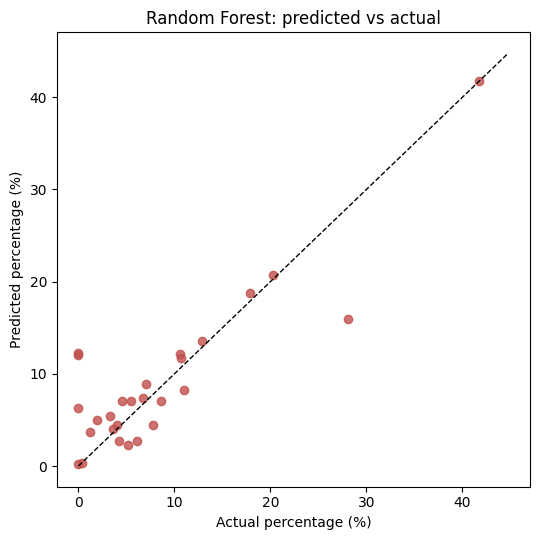

In [26]:
best_name = results_df.iloc[0]["Model"]
y_predict = predictions[best_name]

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_predict, alpha=0.8, color="#c0504d")
lim = [0, max(y_test.max(), y_predict.max()) + 3]
plt.plot(lim, lim, "k--", lw=1)
plt.xlabel("Actual percentage (%)")
plt.ylabel("Predicted percentage (%)")
plt.title(f"{best_name}: predicted vs actual")
plt.tight_layout()
plt.savefig("results/fig6_pred_vs_actual.png", dpi=200)
plt.show()

## 14. Which inputs matter most (Random Forest feature importance)


Top 10 most important features (Random Forest):
Computer                            0.521
is_disabled                         0.184
is_female                           0.054
Ready-made Garments (RMG)           0.046
Other                               0.030
female_x_disabled                   0.024
Non-crop agricultural activities    0.022
Health and paramedical services     0.019
Construction related works          0.018
is_urban                            0.018
dtype: float64


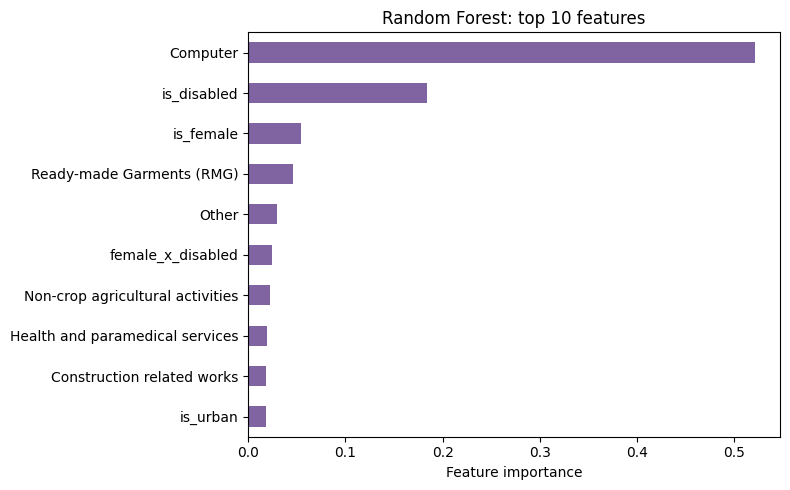


Lasso features set to zero: 2 of 16


In [27]:
rf = models["Random Forest"]
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 most important features (Random Forest):")
print(importance.head(10).round(3))

importance.head(10).iloc[::-1].plot(kind="barh", figsize=(8, 5), color="#8064a2")
plt.xlabel("Feature importance")
plt.title("Random Forest: top 10 features")
plt.tight_layout()
plt.savefig("results/fig7_feature_importance.png", dpi=200)
plt.show()

# Lasso coefficients: features set to zero are not needed by the model
lasso_coef = pd.Series(models["Lasso Regression"].coef_, index=X.columns)
print("\nLasso features set to zero:", int((lasso_coef == 0).sum()), "of", len(lasso_coef))

## 15. Summary of findings

In [28]:
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Best model on the test set: {best_name}")
print(f"Literacy gap (national, total): {gap.loc['Total', 'Gap_pct_points']:.1f} percentage points")
print("\nLimitations:")
print(" - The source tables are aggregated, so the ML dataset is small (about 130 rows).")
print(" - Disabled data is from 2022, general data from 2024.")
print(" - The general population also includes persons with disabilities.")
print("\nAll figures and tables are saved in the 'results' folder.")


SUMMARY
Best model on the test set: Random Forest
Literacy gap (national, total): 41.9 percentage points

Limitations:
 - The source tables are aggregated, so the ML dataset is small (about 130 rows).
 - Disabled data is from 2022, general data from 2024.
 - The general population also includes persons with disabilities.

All figures and tables are saved in the 'results' folder.
